# Proyek Prediksi Risiko Keterlambatan Kelulusan Mahasiswa

Proyek ini bertujuan untuk memprediksi risiko keterlambatan kelulusan berdasarkan data akademik menggunakan algoritma Machine Learning.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. LOAD DATA
file_path = '/content/dataset wisudawan 2019-2026 (1).xlsx'
df = pd.read_excel(file_path)

print("Data berhasil dimuat. Ukuran dataset:", df.shape)
display(df.head())

Data berhasil dimuat. Ukuran dataset: (511, 8)


,NAMA,L/P,IPK,Tahun,Bulan,prestasi,NPM/ STAMBUK,Nama Jurnal
0,AHMAD KHAIRUN ARSYAD,L,3.7,4.0,0.0,tidak ada,E1E115054,Tidak ada
1,MUHAMMAD BUDI DHARMAWAN P,L,3.44,4.0,0.0,tidak ada,E1E115034,Tidak ada
2,WA ODE HARDIANAS SHALAWATI,P,3.48,5.0,0.0,tidak ada,E1E114041,Tidak ada
3,MUH. MUCHSIN AL- AS'AD MIRSYAH,L,3.15,4.0,10.0,tidak ada,E1E114025,Tidak ada
4,IDZANUL IKSAN SINATRA,L,3.41,5.0,0.0,tidak ada,E1E114072,Tidak ada


## Data Cleaning & Preprocessing

Pada tahap ini, kita akan:
- Menghapus kolom identitas (Stambuk dan Nama).
- Mengubah kolom `prestasi` menjadi format biner (0 dan 1).
- Membuat target `label` gabungan dari Tahun dan Bulan (Format: Tahun.Bulan).
- Membersihkan kolom `IPK` agar menjadi tipe data numerik.

In [16]:
# Reload original data to ensure 'tahun' and 'bulan' are present
df_temp = pd.read_excel(file_path)
df_temp.columns = [col.strip().lower() for col in df_temp.columns]

# 1. Hapus identitas (Stambuk & Nama tidak dihitung), TETAPI JAGA 'nama jurnal'
cols_to_drop = []
for col in df_temp.columns:
    lower_col = col.strip().lower()
    if 'stambuk' in lower_col or ('nama' in lower_col and 'jurnal' not in lower_col) or 'npm' in lower_col or 'unnamed' in lower_col:
        cols_to_drop.append(col)

df_clean = df_temp.drop(columns=cols_to_drop, errors='ignore')

# Rename 'nama jurnal' to 'jurnal' for consistency and easier access
if 'nama jurnal' in df_clean.columns:
    df_clean = df_clean.rename(columns={'nama jurnal': 'jurnal'})

# 2. Transformasi kolom 'prestasi' dan 'jurnal' (jika ada)
def map_binary_feature(val):
    if pd.isna(val) or str(val).lower() in ['tidak ada', '0', 'none', 'null', '']:
        return 0
    return 1

if 'prestasi' in df_clean.columns:
    df_clean['prestasi'] = df_clean['prestasi'].apply(map_binary_feature)

if 'jurnal' in df_clean.columns:
    df_clean['jurnal'] = df_clean['jurnal'].apply(map_binary_feature)

# 3. Membersihkan IPK (Memastikan format numerik)
if 'ipk' in df_clean.columns:
    df_clean['ipk'] = pd.to_numeric(df_clean['ipk'], errors='coerce')
    df_clean['ipk'] = df_clean['ipk'].fillna(df_clean['ipk'].median())

# 4. Normalisasi Gender (L/P)
if 'l/p' in df_clean.columns:
    # Ensure 'l/p' column is string type before applying .str methods
    df_clean['l/p'] = df_clean['l/p'].astype(str).str.strip().str.upper().map({'L': 1, 'P': 0}).fillna(1)

# 5. Membuat Label (Tahun dan Bulan digabung, misal 4 & 2 jadi 4.2)
t_col_list = [c for c in df_clean.columns if 'tahun' in c]
b_col_list = [c for c in df_clean.columns if 'bulan' in c]

if t_col_list and b_col_list:
    t_col = t_col_list[0]
    b_col = b_col_list[0]

    df_clean['label_float'] = df_clean[t_col].fillna(0).astype(float) + (df_clean[b_col].fillna(0).astype(float) / 10.0)

    # Menentukan Target Klasifikasi: 1 (Risiko Terlambat > 4.0), 0 (Tepat Waktu <= 4.0)
    df_clean['label_kategori'] = (df_clean['label_float'] > 4.0).astype(int)

    # Hapus kolom mentah yang tidak digunakan lagi
    df_final = df_clean.drop(columns=[t_col, b_col, 'label_float'])
else:
    raise ValueError("Columns 'tahun' or 'bulan' not found after initial cleaning. Please ensure raw data has these columns.")


print("Preprocessing selesai. Data siap diproses:")
display(df_final.head())

Preprocessing selesai. Data siap diproses:


,l/p,ipk,prestasi,jurnal,label_kategori
0,1.0,3.70,0,0,0
1,1.0,3.44,0,0,0
2,0.0,3.48,0,0,1
3,1.0,3.15,0,0,1
4,1.0,3.41,0,0,1


### Visualisasi Distribusi IPK berdasarkan Status Kelulusan

Karena 'ipk' (GPA) adalah fitur yang paling berpengaruh, mari kita lihat bagaimana distribusinya berbeda antara mahasiswa yang lulus tepat waktu (0) dan yang terlambat (1).

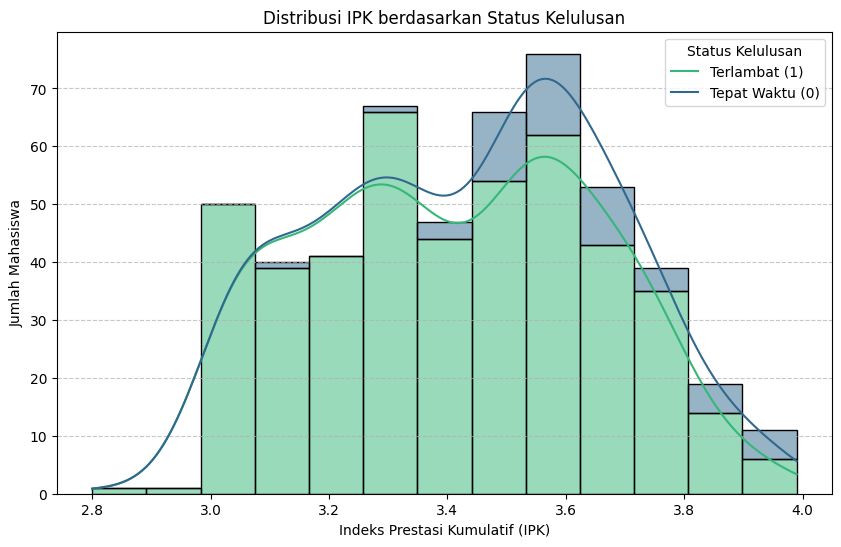

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=df_final, x='ipk', hue='label_kategori', kde=True, palette='viridis', multiple='stack')
plt.title('Distribusi IPK berdasarkan Status Kelulusan')
plt.xlabel('Indeks Prestasi Kumulatif (IPK)')
plt.ylabel('Jumlah Mahasiswa')
plt.legend(title='Status Kelulusan', labels=['Terlambat (1)', 'Tepat Waktu (0)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Visualisasi Fitur Kategorikal (Gender dan Prestasi) berdasarkan Status Kelulusan

Selanjutnya, mari kita visualisasikan bagaimana distribusi fitur kategorikal seperti gender (`l/p`) dan prestasi terhadap status kelulusan.

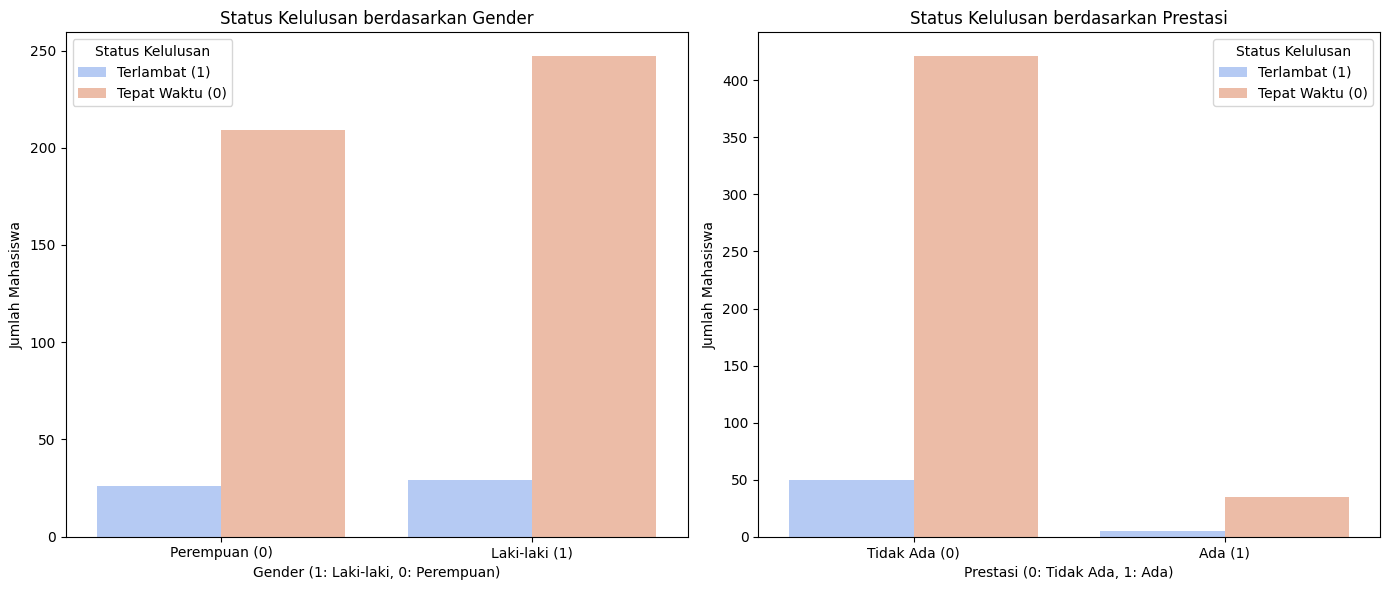

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(data=df_final, x='l/p', hue='label_kategori', palette='coolwarm', ax=axes[0])
axes[0].set_title('Status Kelulusan berdasarkan Gender')
axes[0].set_xlabel('Gender (1: Laki-laki, 0: Perempuan)')
axes[0].set_ylabel('Jumlah Mahasiswa')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Perempuan (0)', 'Laki-laki (1)'])
axes[0].legend(title='Status Kelulusan', labels=['Terlambat (1)', 'Tepat Waktu (0)'])

sns.countplot(data=df_final, x='prestasi', hue='label_kategori', palette='coolwarm', ax=axes[1])
axes[1].set_title('Status Kelulusan berdasarkan Prestasi')
axes[1].set_xlabel('Prestasi (0: Tidak Ada, 1: Ada)')
axes[1].set_ylabel('Jumlah Mahasiswa')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Tidak Ada (0)', 'Ada (1)'])
axes[1].legend(title='Status Kelulusan', labels=['Terlambat (1)', 'Tepat Waktu (0)'])

plt.tight_layout()
plt.show()

### Visualisasi Fitur Kategorikal (Jurnal) berdasarkan Status Kelulusan

Untuk melengkapi analisis fitur kategorikal, mari kita lihat bagaimana distribusi 'jurnal' (apakah mahasiswa memiliki publikasi jurnal atau tidak) terhadap status kelulusan.

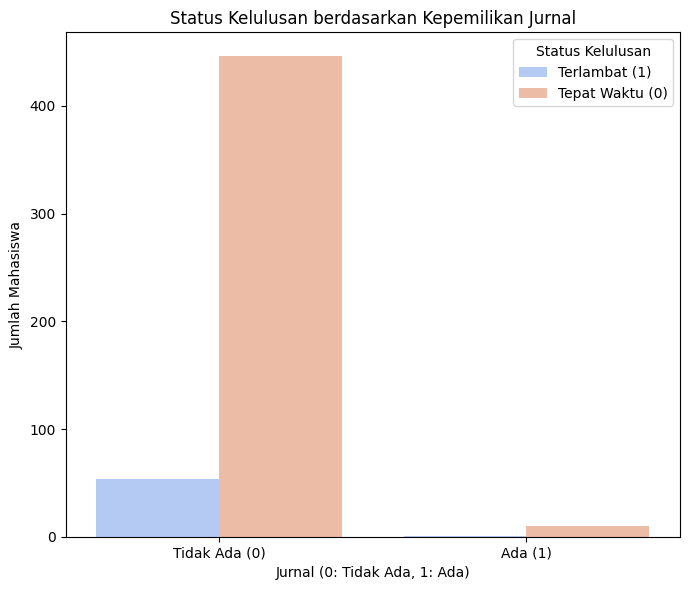

In [19]:
plt.figure(figsize=(7, 6))
sns.countplot(data=df_final, x='jurnal', hue='label_kategori', palette='coolwarm')
plt.title('Status Kelulusan berdasarkan Kepemilikan Jurnal')
plt.xlabel('Jurnal (0: Tidak Ada, 1: Ada)')
plt.ylabel('Jumlah Mahasiswa')
plt.xticks([0, 1], ['Tidak Ada (0)', 'Ada (1)'])
plt.legend(title='Status Kelulusan', labels=['Terlambat (1)', 'Tepat Waktu (0)'])
plt.tight_layout()
plt.show()

## Pembagian Data (Train-Test Split)

Kita membagi data menjadi set Pelatihan (80%) dan set Pengujian (20%).

In [20]:
# Menentukan Fitur (X) dan Target (y)
X = df_final.drop(columns=['label_kategori'])
y = df_final['label_kategori']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Data Latih: {X_train.shape[0]} baris")
print(f"Data Uji: {X_test.shape[0]} baris")

Data Latih: 408 baris
Data Uji: 103 baris


## Pelatihan Model (Random Forest Classifier)

Algoritma Random Forest digunakan karena handal dalam menangani data numerik dan kategorikal secara bersamaan.

In [21]:
# Inisialisasi Model
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Melatih Model
model_rf.fit(X_train, y_train)

print("Model Random Forest berhasil dilatih.")

Model Random Forest berhasil dilatih.


## Evaluasi Model

Melihat performa model dalam memprediksi data yang belum pernah dilihat sebelumnya.

--- LAPORAN KLASIFIKASI ---
Akurasi Keseluruhan: 83.50%

Detail Laporan:
              precision    recall  f1-score   support

           0       0.12      0.09      0.11        11
           1       0.89      0.92      0.91        92

    accuracy                           0.83       103
   macro avg       0.51      0.51      0.51       103
weighted avg       0.81      0.83      0.82       103



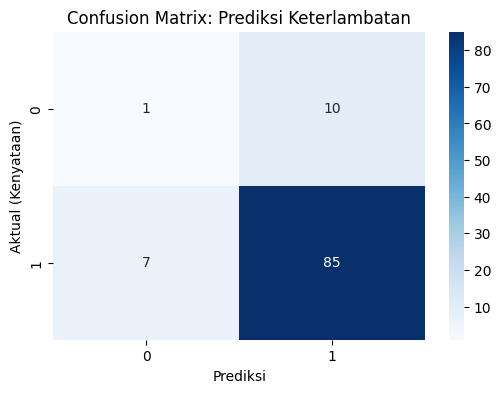

In [22]:
# Prediksi
y_pred = model_rf.predict(X_test)

# Metrik Evaluasi
print("--- LAPORAN KLASIFIKASI ---")
print(f"Akurasi Keseluruhan: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nDetail Laporan:")
print(classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Aktual (Kenyataan)')
plt.title('Confusion Matrix: Prediksi Keterlambatan')
plt.show()

## Analisis Fitur Terpenting

Mengetahui faktor apa saja yang paling memengaruhi risiko keterlambatan mahasiswa.

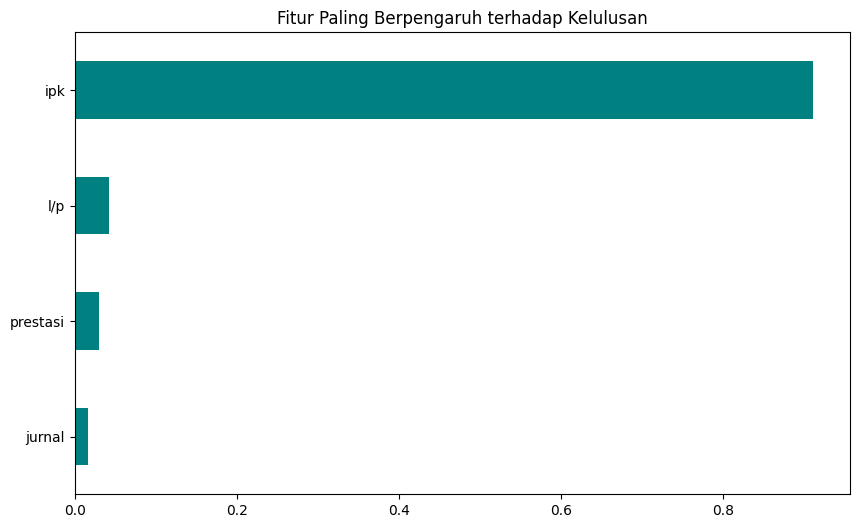

In [23]:
importances = pd.Series(model_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.plot(kind='barh', color='teal')
plt.title('Fitur Paling Berpengaruh terhadap Kelulusan')
plt.gca().invert_yaxis()
plt.show()

### Visualisasi Perbandingan Aktual vs Prediksi

Untuk memahami mengapa kita menggunakan akurasi, mari kita lihat perbandingan antara status asli mahasiswa (Aktual) dengan hasil tebakan model (Prediksi).

In [24]:
comparison_df = pd.DataFrame({'Kenyataan': y_test, 'Tebakan_Model': y_pred}).reset_index(drop=True)

# Menampilkan 10 sampel pertama
print("Perbandingan 10 Data Uji Pertama:")
display(comparison_df.head(10))

# Menghitung jumlah tebakan yang benar
correct_guesses = (comparison_df['Kenyataan'] == comparison_df['Tebakan_Model']).sum()
total_data = len(comparison_df)

print(f"\nDari {total_data} data uji, model menebak dengan benar sebanyak {correct_guesses} kali.")
print(f"Persentase kebenaran (Akurasi): {(correct_guesses/total_data)*100:.2f}%")

Perbandingan 10 Data Uji Pertama:


,Kenyataan,Tebakan_Model
0,1,1
1,1,1
2,0,1
3,1,0
4,1,1
5,1,0
6,1,1
7,1,1
8,1,1
9,1,1



Dari 103 data uji, model menebak dengan benar sebanyak 86 kali.
Persentase kebenaran (Akurasi): 83.50%


In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Data loading and preprocessing is handled by cell b93b39e5,
#    resulting in df_final. We will use df_final directly here.

# 2. MACHINE LEARNING PROCESS
# Features (X) are all columns except 'label_kategori' (which is the target)
X = df_final.drop(columns=['label_kategori'])
y = df_final['label_kategori']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 3. EVALUATION
y_pred = model.predict(X_test)

print("--- HASIL MACHINE LEARNING (VERSI PERBAIKAN) ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFaktor Paling Berpengaruh:")
print(importances)

print("\nSample Data Hasil Preprocessing (df_final digunakan sebagai input model):")
display(df_final.head())

--- HASIL MACHINE LEARNING (VERSI PERBAIKAN) ---
Accuracy Score: 0.83

Classification Report:
              precision    recall  f1-score   support

           0       0.12      0.09      0.11        11
           1       0.89      0.92      0.91        92

    accuracy                           0.83       103
   macro avg       0.51      0.51      0.51       103
weighted avg       0.81      0.83      0.82       103


Faktor Paling Berpengaruh:
ipk         0.911154
l/p         0.042246
prestasi    0.029976
jurnal      0.016625
dtype: float64

Sample Data Hasil Preprocessing (df_final digunakan sebagai input model):


,l/p,ipk,prestasi,jurnal,label_kategori
0,1.0,3.70,0,0,0
1,1.0,3.44,0,0,0
2,0.0,3.48,0,0,1
3,1.0,3.15,0,0,1
4,1.0,3.41,0,0,1


In [26]:
import joblib

# Simpan model Random Forest yang telah dilatih
model_filename = 'random_forest_model.pkl'
joblib.dump(model_rf, model_filename)

print(f"Model berhasil disimpan sebagai '{model_filename}'")

Model berhasil disimpan sebagai 'random_forest_model.pkl'
